# Predicting Customer Churn: A Data-Driven Analysis of Subscription Customer Behaviour Using Machine Learning

**Final Capstone Project — IDRA Data Science & AI**

This notebook follows the IDRA capstone workflow: dataset understanding, data cleaning, preprocessing, EDA, statistical analysis, feature engineering, classification modelling, evaluation, findings and recommendations.

> **Dataset:** LMS-provided Telco Customer Churn CSV.


## 1. Problem Statement and Motivation
Customer churn reduces recurring revenue and increases acquisition costs. The goal is to identify customer characteristics associated with churn and build a classification model that can flag customers who are more likely to leave.

## 2. Objectives and Research Questions
### Objectives
1. Understand the structure and quality of the customer churn dataset.
2. Identify patterns and customer segments associated with churn.
3. Prepare categorical and numerical variables without data leakage.
4. Build and compare classification models for churn prediction.
5. Evaluate the final model using accuracy, precision, recall, F1-score and a confusion matrix.
6. Translate the evidence into practical retention recommendations.

### Research Questions
- What is the overall churn rate?
- Which contract, service and payment groups show higher churn?
- How do tenure and monthly charges differ between churned and retained customers?
- Which variables are most influential in the final model?
- How accurately can churn be predicted on unseen customers?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("P_4_WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [2]:
print("Missing values before cleaning:")
display(df.isna().sum().sort_values(ascending=False))
print("Blank TotalCharges values:", (df["TotalCharges"].astype(str).str.strip()=="").sum())
print("Duplicate rows:", df.duplicated().sum())


Missing values before cleaning:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Blank TotalCharges values: 11
Duplicate rows: 0


## 3. Data Cleaning
`TotalCharges` is stored as object because 11 records contain blank strings. These blanks occur for customers with tenure 0, so after numeric conversion they are treated as missing and filled with 0, representing no accumulated charge yet. No duplicate rows were found. Customer IDs are retained for identification but excluded from modelling.

In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges after numeric conversion:", df["TotalCharges"].isna().sum())
display(df.loc[df["TotalCharges"].isna(), ["customerID","tenure","MonthlyCharges","TotalCharges","Churn"]])
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Missing values after cleaning:", df.isna().sum().sum())


Missing TotalCharges after numeric conversion: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


Missing values after cleaning: 0


## 4. Outlier Analysis
The IQR rule uses lower fence = Q1 − 1.5×IQR and upper fence = Q3 + 1.5×IQR. Outliers are inspected rather than removed automatically.

In [4]:
iqr_vars = ["tenure","MonthlyCharges","TotalCharges"]
rows=[]
for c in iqr_vars:
    q1=df[c].quantile(.25); q3=df[c].quantile(.75); iqr=q3-q1
    lo=q1-1.5*iqr; hi=q3+1.5*iqr
    count=((df[c]<lo)|(df[c]>hi)).sum()
    rows.append([c,q1,q3,iqr,lo,hi,count])
iqr_df=pd.DataFrame(rows,columns=["Variable","Q1","Q3","IQR","Lower_Fence","Upper_Fence","Outlier_Count"])
display(iqr_df.round(3))


,Variable,Q1,Q3,IQR,Lower_Fence,Upper_Fence,Outlier_Count
0,tenure,9.00,55.00,46.00,-60.000,124.000,0
1,MonthlyCharges,35.50,89.85,54.35,-46.025,171.375,0
2,TotalCharges,398.55,3786.60,3388.05,-4683.525,8868.675,0


## 5. Exploratory Data Analysis

In [5]:
df["ChurnFlag"] = df["Churn"].map({"No":0,"Yes":1})
print(f"Overall churn rate: {df['ChurnFlag'].mean():.2%}")
display(df.groupby("Contract")["ChurnFlag"].agg(["count","mean"]).sort_values("mean",ascending=False))
display(df.groupby("InternetService")["ChurnFlag"].agg(["count","mean"]).sort_values("mean",ascending=False))
display(df.groupby("PaymentMethod")["ChurnFlag"].agg(["count","mean"]).sort_values("mean",ascending=False))


Overall churn rate: 26.54%


,count,mean
Contract,,
Month-to-month,3875,0.427097
One year,1473,0.112695
Two year,1695,0.028319


,count,mean
InternetService,,
Fiber optic,3096,0.418928
DSL,2421,0.189591
No,1526,0.074050


,count,mean
PaymentMethod,,
Electronic check,2365,0.452854
Mailed check,1612,0.191067
Bank transfer (automatic),1544,0.167098
Credit card (automatic),1522,0.152431


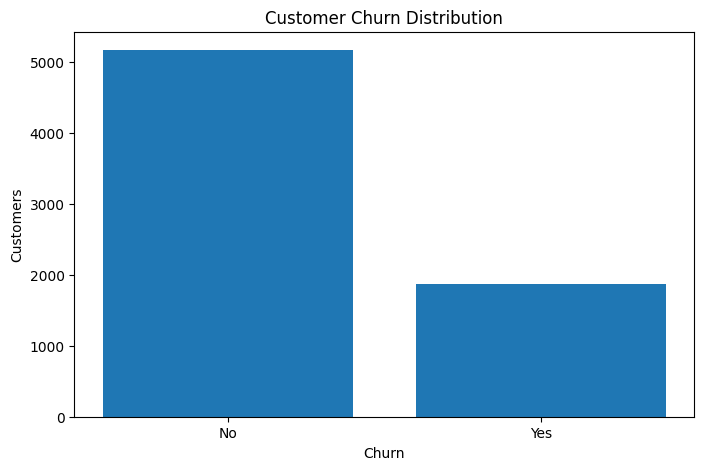

In [6]:
fig, ax = plt.subplots(figsize=(8,5))
counts=df["Churn"].value_counts().reindex(["No","Yes"])
ax.bar(counts.index,counts.values)
ax.set_title("Customer Churn Distribution"); ax.set_xlabel("Churn"); ax.set_ylabel("Customers")
plt.show()


In [7]:
display(df.groupby("Churn")[["tenure","MonthlyCharges","TotalCharges"]].agg(["mean","median"]).round(2))


tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2549.91  1679.52
Yes    17.98   10.0          74.44  79.65      1531.80   703.55

## 6. Statistical Analysis
Key measures are reported for tenure, MonthlyCharges and TotalCharges. Means describe the average level while medians reduce sensitivity to skew. Correlations are descriptive and do not establish causation.

In [8]:
display(df[["tenure","MonthlyCharges","TotalCharges","ChurnFlag"]].describe().T.round(3))
display(df[["SeniorCitizen","tenure","MonthlyCharges","TotalCharges","ChurnFlag"]].corr().round(3))


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371,24.559,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.762,30.090,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734,2266.794,0.00,398.55,1394.55,3786.60,8684.80
ChurnFlag,7043.0,0.265,0.442,0.00,0.00,0.00,1.00,1.00


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChurnFlag
SeniorCitizen,1.000,0.017,0.220,0.103,0.151
tenure,0.017,1.000,0.248,0.826,-0.352
MonthlyCharges,0.220,0.248,1.000,0.651,0.193
TotalCharges,0.103,0.826,0.651,1.000,-0.198
ChurnFlag,0.151,-0.352,0.193,-0.198,1.000


## 7. Feature Engineering and Preprocessing
The target is `Churn`. `customerID` is excluded because it is an identifier, not a meaningful predictor. Categorical variables are one-hot encoded. Numerical variables are median-imputed and standardized. All learned preprocessing is fitted only on the training data through a scikit-learn Pipeline, preventing test-set leakage. A stratified 80/20 split preserves the churn proportion.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

X=df.drop(columns=["Churn","customerID","ChurnFlag"])
y=df["ChurnFlag"]
cat_cols=X.select_dtypes(include="object").columns.tolist()
num_cols=X.select_dtypes(exclude="object").columns.tolist()

preprocessor=ColumnTransformer([
    ("num",Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())]),num_cols),
    ("cat",Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(handle_unknown="ignore"))]),cat_cols)
])

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=.20,random_state=42,stratify=y
)
print("Training rows:",len(X_train),"Testing rows:",len(X_test))


Training rows: 5634 Testing rows: 1409


## 8. Model Development

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

models={
    "Logistic Regression":LogisticRegression(max_iter=2000),
    "Random Forest":RandomForestClassifier(
        n_estimators=300,max_depth=8,min_samples_leaf=3,
        class_weight="balanced",random_state=42
    )
}
results={}
for name,model in models.items():
    pipe=Pipeline([("preprocessor",preprocessor),("model",model)])
    pipe.fit(X_train,y_train)
    pred=pipe.predict(X_test)
    prob=pipe.predict_proba(X_test)[:,1]
    results[name]={
        "model":pipe,
        "accuracy":accuracy_score(y_test,pred),
        "precision":precision_score(y_test,pred),
        "recall":recall_score(y_test,pred),
        "f1":f1_score(y_test,pred),
        "roc_auc":roc_auc_score(y_test,prob),
        "train_accuracy":accuracy_score(y_train,pipe.predict(X_train)),
        "cm":confusion_matrix(y_test,pred)
    }

comparison=pd.DataFrame({
    k:{m:v for m,v in r.items() if m not in ["model","cm"]}
    for k,r in results.items()
}).T
display(comparison.round(4))


,accuracy,precision,recall,f1,roc_auc,train_accuracy
Logistic Regression,0.8055,0.6572,0.5588,0.604,0.8421,0.8056
Random Forest,0.7630,0.5366,0.7834,0.637,0.8416,0.7973


### Why recall matters for churn
For a retention use case, a **false negative** means a customer who actually churns is not flagged by the model. Missing such a customer can mean a missed opportunity for retention. A false positive may cause an unnecessary retention contact or offer. Because the business objective emphasizes identifying potential churners, recall and F1-score are given more weight than accuracy alone.

The Logistic Regression baseline has higher accuracy (0.8055) and essentially the same ROC-AUC (0.8421), while Random Forest has higher recall (0.7834 vs 0.5588) and F1-score (0.6370 vs 0.6040). Therefore, Random Forest is selected as the final screening model for this particular retention objective.

## 9. Model Evaluation

In [11]:
final=results["Random Forest"]
print("Random Forest confusion matrix:")
print(final["cm"])
print(f"Accuracy : {final['accuracy']:.4f}")
print(f"Precision: {final['precision']:.4f}")
print(f"Recall   : {final['recall']:.4f}")
print(f"F1-score : {final['f1']:.4f}")
print(f"ROC-AUC  : {final['roc_auc']:.4f}")
print(f"Train accuracy: {final['train_accuracy']:.4f}")
print(f"Test accuracy : {final['accuracy']:.4f}")


Random Forest confusion matrix:
[[782 253]
 [ 81 293]]
Accuracy : 0.7630
Precision: 0.5366
Recall   : 0.7834
F1-score : 0.6370
ROC-AUC  : 0.8416
Train accuracy: 0.7973
Test accuracy : 0.7630


### Overfitting / Underfitting
Training and test accuracy are compared. A small difference suggests the selected Random Forest configuration is not showing severe accuracy overfitting. Because churn detection values recall, the final model is selected based on its stronger recall and F1-score compared with the logistic baseline.

In [12]:
feat_names=final["model"].named_steps["preprocessor"].get_feature_names_out()
importance=pd.Series(
    final["model"].named_steps["model"].feature_importances_,
    index=feat_names
).sort_values(ascending=False).head(12)
display(importance.to_frame("importance"))


,importance
cat__Contract_Month-to-month,0.148061
num__tenure,0.126302
num__TotalCharges,0.083465
cat__OnlineSecurity_No,0.074794
cat__Contract_Two year,0.074348
cat__InternetService_Fiber optic,0.056804
cat__TechSupport_No,0.056414
num__MonthlyCharges,0.056023
cat__PaymentMethod_Electronic check,0.038145
cat__Contract_One year,0.021729


## 10. Findings, Discussion and Recommendations

**Finding 1 — Churn is a substantial minority outcome.** The dataset contains a meaningful churn segment, so accuracy alone should not be the only model criterion.

**Finding 2 — Contract type is strongly associated with churn.** Month-to-month customers have a much higher observed churn rate than one-year and two-year customers.

**Finding 3 — Tenure differs materially by churn status.** Churned customers have substantially shorter average tenure than retained customers, indicating that early customer lifecycle stages deserve attention.

**Finding 4 — Monthly charges are higher among churned customers.** This relationship suggests that price/value perception may matter, although the observational data cannot establish causality.

**Finding 5 — Service and payment characteristics add predictive signal.** Features such as contract, tenure, security/support services, internet service and payment method appear among important model inputs.

### Recommendations
1. Prioritize retention offers for month-to-month customers.
2. Strengthen onboarding during the first months of tenure.
3. Review pricing/value communication for higher-charge customers.
4. Encourage adoption of security and support services where appropriate.
5. Use the model as a screening tool for proactive retention outreach, with human review before action.


## 11. Limitations
- The dataset is observational, so associations should not be interpreted as causal effects.
- Customer churn can be influenced by variables not present in the dataset.
- Model performance depends on the historical population and may change over time.
- The Random Forest feature-importance values indicate predictive usefulness, not causal importance.
- Thresholds could be tuned further if the business has a specific cost for false negatives versus false positives.


## 12. Conclusion
The analysis demonstrates a complete data science workflow for customer churn prediction. Contract type, tenure, monthly charges, service-related variables and payment method provide useful signals for identifying churn risk. The final Random Forest model provides a practical classification baseline, with recall and F1-score making it particularly useful when the business wants to identify more potential churners. The model should support, not replace, customer-retention decision making.
